# 4.10 Pronóstico de series de tiempo

Pronosticar significa predecir valores futuros de una serie de tiempo a partir de su pasado. Las geociencias funcionan a base de pronósticos: CO$_2$ atmosférico, caudal de ríos, flujo de glaciares, niveles de agua subterránea, clima espacial. Este cuaderno es un duelo de pronósticos. Tomamos las familias de modelos canónicas que usted ya conoció en este libro, las apuntamos todas a los mismos dos conjuntos de datos reales, las evaluamos con las mismas métricas sobre la misma división temporal y dejamos que una tabla comparativa decida.

Los contendientes, en orden creciente de complejidad:

1. **Modelos de referencia**: persistencia ingenua e ingenuo estacional. Siempre primero.
2. **SARIMA**: un modelo estadístico clásico (`statsmodels`).
3. ***Gradient boosting* (potenciación de gradiente) sobre características de rezago** (`lightgbm`): aprendizaje automático clásico del capítulo 3, adaptado al tiempo.
4. **Un LSTM pequeño** (`torch`): la arquitectura recurrente del cuaderno 4.4.
5. **Un codificador *transformer* pequeño** (`torch`): el patrón de atención del cuaderno 4.4.

Los datos:

- **CO$_2$ mensual de Mauna Loa** (NOAA Global Monitoring Laboratory): larga, regular, fuertemente estacional, con una tendencia suave. El caso amable, y el punto de referencia principal.
- **Velocidad superficial del Jakobshavn Isbrae** (Groenlandia): corta, muestreada de manera irregular, ruidosa. El caso difícil.

**Objetivos de aprendizaje**

- Dividir datos de series de tiempo de manera temporal y explicar por qué las divisiones aleatorias filtran información del futuro.
- Construir características de rezago que usen únicamente el pasado.
- Evaluar pronósticos con MSE, RMSE, MAE, MAPE y MASE, calculados en código.
- Convertir un pronosticador puntual en uno probabilístico con la pérdida pinball (*pinball loss*), y luego verificarlo: cobertura empírica del intervalo del 90% y CRPS.
- Medir cómo crece el error de pronóstico con el horizonte de pronóstico y localizar el horizonte de *skill* (habilidad de pronóstico).
- Cuantificar cuánto se mueve el ordenamiento de los modelos entre semillas aleatorias, y calificar los eventos raros por separado del grueso de los datos.
- Juzgar cuándo la complejidad del modelo rinde y cuándo gana un modelo de referencia.

El cuaderno termina con una tabla de clasificación (*leaderboard*) de la clase en dos pistas: un pronóstico público de CO$_2$ que es solo un diagnóstico (la sección 7 explica por qué es trivialmente manipulable, y por qué lo decimos por escrito), y una serie sintética oculta que carga con el peso de la calificación.

🖥️ [**Diapositivas de clase — Sesión 26 (mié 2 dic)**](https://geo-smart.github.io/mlgeo-book/slides/2026/lec26_forecasting.html)

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pooch
import torch
import torch.nn as nn

import mlgeo_synth

np.random.seed(0)
torch.manual_seed(0)

device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available()
                      else "cpu")
print("device:", device)

# One fixed color per model, reused in every figure (Okabe-Ito palette, colorblind-safe).
COLORS = {
    "observations":   "#000000",
    "naive":          "#999999",
    "seasonal naive": "#E69F00",
    "SARIMA":         "#0072B2",
    "ARIMA":          "#0072B2",
    "LightGBM":       "#009E73",
    "LSTM":           "#D55E00",
    "Transformer":    "#CC79A7",
}
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})

device: mps


## 1. Datos

### 1.1 CO$_2$ mensual de Mauna Loa

El registro de Mauna Loa es la medición directa continua más larga del CO$_2$ atmosférico, iniciada por Charles Keeling en 1958. NOAA GML distribuye promedios mensuales en un archivo de texto: unas 42 líneas de comentarios con `#`, una línea de encabezado y luego columnas separadas por espacios (año, mes, fecha decimal, promedio mensual en ppm, valor desestacionalizado, número de días, desviación estándar, incertidumbre). Lo descargamos con `pooch`, que guarda el archivo en caché local.

In [2]:
co2_url = "https://raw.githubusercontent.com/UW-MLGEO/MLGeo-dataset/main/data/data_co2.csv"
co2_file = pooch.retrieve(co2_url, known_hash=None, fname="data_co2.csv")

co2 = pd.read_csv(co2_file, comment="#", sep=r"\s+", header=0)
co2.columns = ["year", "month", "decimal_date", "average",
               "deseasonalized", "ndays", "stdev", "unc"]
co2.index = pd.to_datetime(co2["year"].astype(str) + "-"
                           + co2["month"].astype(str).str.zfill(2))
y_full = co2["average"].astype("float64")
print(y_full.shape, "monthly values,", y_full.index[0].date(), "to", y_full.index[-1].date())

(798,) monthly values, 1958-03-01 to 2024-08-01


### 1.2 El conjunto reservado de la tabla de clasificación: no toque los últimos 12 meses

Antes de cualquier modelado, quitamos los 12 meses finales del registro: **2023-09 a 2024-08**. Esos meses son el conjunto reservado de la tabla de clasificación de la clase (sección 7) — un conjunto de prueba que calificaremos exactamente una vez. Nada en las secciones de modelado los toca: ninguna gráfica, ningún ajuste, ninguna métrica. Conservamos solo sus fechas.

In [3]:
holdout_months = y_full.index[-12:]
y = y_full.iloc[:-12].copy()
del y_full  # the holdout values are gone from this notebook

assert holdout_months[0] == pd.Timestamp("2023-09-01")
assert holdout_months[-1] == pd.Timestamp("2024-08-01")
print("holdout months:", holdout_months.strftime("%Y-%m").tolist())
print("working series:", y.index[0].date(), "to", y.index[-1].date(), f"({len(y)} months)")

holdout months: ['2023-09', '2023-10', '2023-11', '2023-12', '2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06', '2024-07', '2024-08']
working series: 1958-03-01 to 2023-08-01 (786 months)


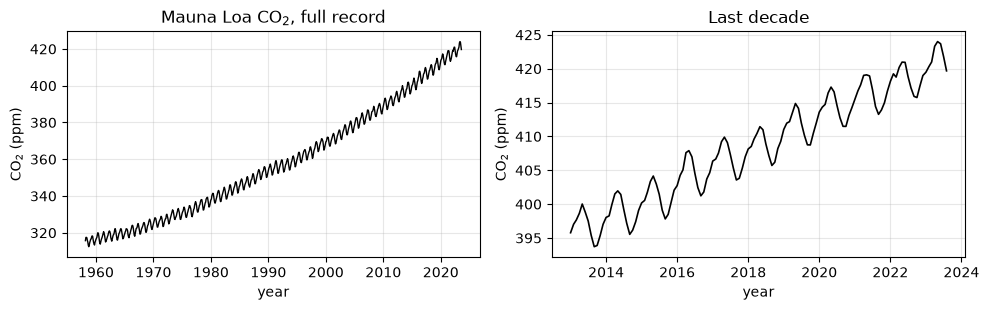

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].plot(y.index, y.values, color=COLORS["observations"], lw=1)
axes[0].set_title("Mauna Loa CO$_2$, full record")
axes[1].plot(y.loc["2013":].index, y.loc["2013":].values,
             color=COLORS["observations"], lw=1.2)
axes[1].set_title("Last decade")
for ax in axes:
    ax.set_xlabel("year")
    ax.set_ylabel("CO$_2$ (ppm)")
fig.tight_layout()
plt.show()

Una tendencia suave que se acelera, más un ciclo anual en diente de sierra (la vegetación del hemisferio norte consume CO$_2$ cada verano). Estructura altamente predecible. Cualquier modelo que no pueda ganarle aquí a «repetir la forma del año pasado» debería avergonzar a su autor.

### 1.3 Velocidad superficial del Jakobshavn Isbrae

El Jakobshavn Isbrae, en el oeste de Groenlandia, es uno de los glaciares más rápidos de la Tierra. El archivo contiene la velocidad superficial derivada de satélite (m/año) para un parche de 10 x 10 píxeles cerca del frente, muestreada de manera irregular (cada 6 a 12 días) desde 2015. Los valores faltantes están codificados como `-1.0`; los enmascaramos como NaN y promediamos los píxeles válidos de cada fecha en una única serie de velocidad media.

(430,) samples, 2015-01-01 to 2024-04-13
median sampling interval: 6 days 00:00:00


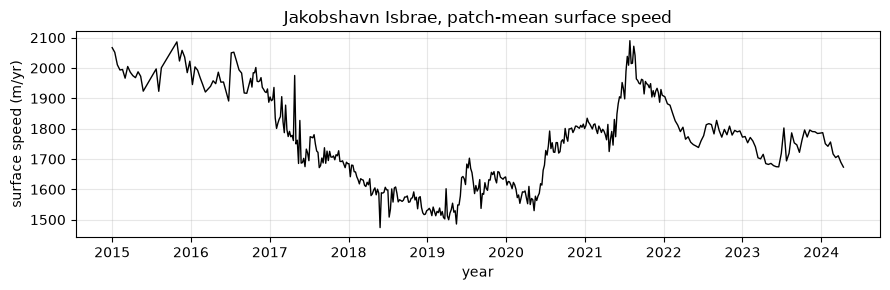

In [5]:
ice_url = "https://raw.githubusercontent.com/UW-MLGEO/MLGeo-dataset/main/data/data_ice_jakobshavn.csv"
ice_file = pooch.retrieve(ice_url, known_hash=None, fname="data_ice_jakobshavn.csv")

ice_raw = pd.read_csv(ice_file, parse_dates=["Date"]).set_index("Date")
ice_raw = ice_raw.where(ice_raw != -1.0)          # -1.0 means missing
ice = ice_raw.mean(axis=1).dropna()               # patch mean over valid pixels
print(ice.shape, "samples,", ice.index[0].date(), "to", ice.index[-1].date())
print("median sampling interval:", ice.index.to_series().diff().median())

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(ice.index, ice.values, color=COLORS["observations"], lw=1)
ax.set_xlabel("year")
ax.set_ylabel("surface speed (m/yr)")
ax.set_title("Jakobshavn Isbrae, patch-mean surface speed")
fig.tight_layout()
plt.show()

Las aceleraciones de verano cabalgan sobre oscilaciones plurianuales ligadas a la posición del frente y al forzamiento oceánico. Comparada con el CO$_2$, esta serie es corta (unas 430 muestras a lo largo de nueve años), muestreada de manera irregular, y su variabilidad no está dominada por un ciclo repetitivo limpio.

## 2. Protocolo de evaluación

### 2.1 Divisiones temporales, idénticas para todos los modelos

Un modelo de pronóstico solo se pone a prueba de manera justa con datos posteriores a **todo** aquello con lo que fue entrenado. Una división aleatoria de entrenamiento y prueba sobre las filas de una serie de tiempo le permite al modelo interpolar entre vecinos de los puntos de prueba, lo que infla los puntajes y no pronostica nada. Todos los modelos de abajo usan exactamente estas divisiones:

- **CO$_2$**: PRUEBA = los últimos 48 meses de la serie de trabajo, **2019-09 a 2023-08**. ENTRENAMIENTO = todo lo anterior, **1958-03 a 2019-08**.
- **Hielo**: PRUEBA = el último 20% de las fechas. ENTRENAMIENTO = el primer 80%.

Todos los modelos pronostican la ventana de prueba completa de una sola vez (un horizonte de 48 meses para el CO$_2$), sin espiar los valores de prueba por el camino.

In [6]:
H_CO2 = 48
train_co2, test_co2 = y.iloc[:-H_CO2], y.iloc[-H_CO2:]
assert test_co2.index[0] == pd.Timestamp("2019-09-01")
assert test_co2.index[-1] == pd.Timestamp("2023-08-01")

n_test_ice = int(0.2 * len(ice))
train_ice, test_ice = ice.iloc[:-n_test_ice], ice.iloc[-n_test_ice:]

print(f"CO2 : train {train_co2.index[0].date()} .. {train_co2.index[-1].date()} "
      f"({len(train_co2)}), test {test_co2.index[0].date()} .. {test_co2.index[-1].date()} ({len(test_co2)})")
print(f"ice : train {train_ice.index[0].date()} .. {train_ice.index[-1].date()} "
      f"({len(train_ice)}), test {test_ice.index[0].date()} .. {test_ice.index[-1].date()} ({len(test_ice)})")

CO2 : train 1958-03-01 .. 2019-08-01 (738), test 2019-09-01 .. 2023-08-01 (48)
ice : train 2015-01-01 .. 2021-09-20 (344), test 2021-09-26 .. 2024-04-13 (86)


### 2.2 Métricas

Con errores de pronóstico $e_t = y_t - \hat{y}_t$ sobre los $n$ puntos de prueba:

- **MSE** $= \frac{1}{n}\sum e_t^2$. Penaliza los errores grandes de manera cuadrática; las unidades quedan al cuadrado, así que es incómodo de leer.
- **RMSE** $= \sqrt{\mathrm{MSE}}$. De vuelta en las unidades de los datos; sigue dominado por los errores más grandes.
- **MAE** $= \frac{1}{n}\sum |e_t|$. Unidades de los datos, trata todos los errores de manera lineal. El más fácil de interpretar.
- **MAPE** $= \frac{100}{n}\sum |e_t / y_t|$. Porcentaje sin unidades, pero se dispara cerca de valores nulos y es asimétrico (los sobrepronósticos y los subpronósticos se penalizan de manera distinta). Está bien para el CO$_2$ (~420 ppm) y para la velocidad del hielo, e inservible para series que cruzan el cero.
- **MASE** (error absoluto medio escalado): el MAE dividido entre el MAE del pronóstico ingenuo de un paso ($\hat{y}_t = y_{t-1}$) **sobre los datos de entrenamiento**. Un MASE $< 1$ significa que el modelo le gana a la persistencia ingenua en su propio juego de un paso; un MASE $> 1$ significa que una regla de «repetir el último valor» era mejor. No tiene unidades, está definido en cero y es comparable entre series, y por eso la tabla de clasificación de la clase lo usa.

Un solo ayudante calcula las cinco. **Todos los números de las tablas comparativas salen de esta función.** Nunca escriba a mano los valores de las métricas en una tabla; la edición 2024 de este cuaderno lo hizo, y la tabla estaba equivocada.

In [7]:
def forecast_metrics(y_true, y_pred, y_train):
    """All metrics for one forecast. MASE is scaled by the training
    MAE of the naive one-step forecast (y_hat_t = y_{t-1})."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    e = y_true - y_pred
    mse = np.mean(e**2)
    mae = np.mean(np.abs(e))
    naive_train_mae = np.mean(np.abs(np.diff(np.asarray(y_train, dtype=float))))
    return {"MSE": mse,
            "RMSE": np.sqrt(mse),
            "MAE": mae,
            "MAPE (%)": 100 * np.mean(np.abs(e / y_true)),
            "MASE": mae / naive_train_mae}

results_co2, preds_co2 = {}, {}   # metrics and predictions, filled model by model
results_ice, preds_ice = {}, {}

def register(results, preds, name, y_pred, test, train):
    preds[name] = np.asarray(y_pred, dtype=float)
    results[name] = forecast_metrics(test.values, y_pred, train.values)
    print(name, "->", {k: round(v, 3) for k, v in results[name].items()})

## 3. El duelo sobre el CO$_2$

### 3.1 Modelos de referencia primero, siempre

- **Persistencia ingenua**: repetir el último valor de entrenamiento a lo largo de todo el horizonte de 48 meses.
- **Ingenuo estacional**: repetir los últimos 12 meses de entrenamiento, replicados cuatro veces. Esto copia la forma estacional del año pasado pero congela la tendencia.

Si un modelo no puede ganarles a estos, su complejidad no compró nada.

In [8]:
naive = np.full(H_CO2, train_co2.iloc[-1])
seasonal = np.tile(train_co2.values[-12:], H_CO2 // 12)

register(results_co2, preds_co2, "naive", naive, test_co2, train_co2)
register(results_co2, preds_co2, "seasonal naive", seasonal, test_co2, train_co2)

naive -> {'MSE': np.float64(56.38), 'RMSE': np.float64(7.509), 'MAE': np.float64(6.679), 'MAPE (%)': np.float64(1.596), 'MASE': np.float64(6.09)}
seasonal naive -> {'MSE': np.float64(41.971), 'RMSE': np.float64(6.478), 'MAE': np.float64(5.961), 'MAPE (%)': np.float64(1.427), 'MASE': np.float64(5.436)}


### 3.2 SARIMA

SARIMA (ARIMA estacional) modela la serie diferenciada con términos autorregresivos y de media móvil, más sus contrapartes estacionales en el rezago 12. Usamos el orden estándar de manual para Mauna Loa, $(1,1,1)\times(1,1,1)_{12}$: una diferencia regular para la tendencia y una diferencia estacional para el ciclo anual. Limitamos las iteraciones del optimizador para que el ajuste sea rápido; esta es una entrada de comparativa, no un ejercicio de ajuste fino.

In [9]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sarima = SARIMAX(train_co2, order=(1, 1, 1),
                     seasonal_order=(1, 1, 1, 12)).fit(disp=False, maxiter=50)
sarima_pred = sarima.forecast(H_CO2).values
register(results_co2, preds_co2, "SARIMA", sarima_pred, test_co2, train_co2)

SARIMA -> {'MSE': np.float64(0.129), 'RMSE': np.float64(0.359), 'MAE': np.float64(0.281), 'MAPE (%)': np.float64(0.067), 'MASE': np.float64(0.256)}


### 3.3 *Gradient boosting* sobre características de rezago

Los ensambles de árboles no saben nada del tiempo. Se lo entregamos explícitamente, como una tabla en la que cada fila predice un mes a partir de características construidas **solo con meses anteriores**:

- rezagos 1, 2, 3, 6, 12, 24 (el valor $k$ meses antes del objetivo),
- la media móvil de los 12 meses **anteriores** al objetivo (es decir, desplazada un paso para excluir al objetivo mismo),
- el mes calendario (conocido de antemano, así que es de juego limpio).

Una sutileza: un árbol de regresión predice promedios de los objetivos de entrenamiento, así que nunca puede producir un valor fuera del rango que vio al entrenar. El CO$_2$ sigue subiendo más allá de todo valor de entrenamiento, de modo que un árbol que predice el *nivel* se satura cerca del máximo de entrenamiento y el pronóstico se aplana. El arreglo es predecir el **cambio de un mes** y sumarlo al valor anterior; los cambios mensuales son aproximadamente estacionarios y quedan bien dentro del rango de entrenamiento. Las características siguen siendo los mismos rezagos que solo miran al pasado.

El modelo predice un paso hacia adelante. Para cubrir la ventana de prueba de 48 meses pronosticamos de manera **recursiva**: predecir el siguiente cambio, sumarlo al último valor, anexar esa predicción al historial, volver a construir características, y así sucesivamente. Los errores se acumulan, lo cual es honesto; el modelo no recibe ninguna observación real del periodo de prueba.

```{admonition} Qué salió mal en 2024
:class: warning
La edición 2024 de este cuaderno dividió la tabla de características de rezago con `train_test_split`, es decir, al azar. Las filas de prueba quedaban entre filas de entrenamiento de meses adyacentes, y una media móvil sin desplazar incluía el propio mes objetivo. Ambas cosas filtran información del futuro hacia el entrenamiento, y los puntajes se veían mucho mejores de lo que ningún pronóstico real podría ser. Aquí la división es estrictamente temporal y cada característica se construye solo con el pasado.
```

In [10]:
from lightgbm import LGBMRegressor

def lag_feature_row(history, date, lags, roll):
    """Features for predicting the value at `date`, given all values before it."""
    row = {f"lag_{k}": history[-k] for k in lags}
    row[f"rollmean_{roll}"] = np.mean(history[-roll:])
    row["month"] = date.month
    return row

def build_training_table(series, lags, roll):
    """One row per predictable month; the target is the one-step change."""
    vals = series.to_numpy()
    start = max(max(lags), roll)          # first row with a full feature set
    rows = [lag_feature_row(vals[:i], series.index[i], lags, roll)
            for i in range(start, len(vals))]
    target = vals[start:] - vals[start - 1:-1]   # y_t - y_{t-1}
    return pd.DataFrame(rows), target

def lgbm_recursive_forecast(train_series, test_index, lags, roll, random_state=0):
    X_tr, y_tr = build_training_table(train_series, lags, roll)
    model = LGBMRegressor(n_estimators=300, learning_rate=0.05,
                          num_leaves=15, random_state=random_state, verbose=-1)
    model.fit(X_tr, y_tr)
    history = list(train_series.to_numpy())
    preds = []
    for date in test_index:               # recursive multi-step
        row = pd.DataFrame([lag_feature_row(np.asarray(history), date, lags, roll)])
        step = float(model.predict(row)[0])       # predicted change
        level = history[-1] + step
        preds.append(level)
        history.append(level)             # feed the prediction back in
    return np.array(preds), model

In [11]:
lgbm_pred_co2, _ = lgbm_recursive_forecast(train_co2, test_co2.index,
                                           lags=[1, 2, 3, 6, 12, 24], roll=12)
register(results_co2, preds_co2, "LightGBM", lgbm_pred_co2, test_co2, train_co2)

LightGBM -> {'MSE': np.float64(1.643), 'RMSE': np.float64(1.282), 'MAE': np.float64(1.03), 'MAPE (%)': np.float64(0.246), 'MASE': np.float64(0.939)}


### 3.4 Un LSTM pequeño

Los modelos profundos pronostican de manera **directa**: una sola pasada hacia adelante (*forward pass*) mapea una ventana de contexto de 36 meses a los 48 valores del horizonte de una vez (sin recursión). Dos puntos prácticos:

- **Anclaje.** El CO$_2$ tiene una tendencia creciente para siempre, así que las ventanas de prueba se sitúan en niveles que la red nunca vio al entrenar. Restamos el último valor de contexto (el «ancla») de cada ventana, entrenamos sobre las formas ancladas y volvemos a sumar el ancla a la predicción. La red aprende el *cambio relativo al ahora*, que es lo bastante estacionario para generalizar.
- **Escalado.** Las ventanas ancladas se dividen entre una única desviación estándar global de las ventanas de entrenamiento, manteniendo las entradas en O(1).

El modelo es pequeño y entrena unas pocas épocas; suba ambas cosas en su propia máquina si quiere.

In [12]:
def make_windows(values, context, horizon):
    """Anchored (context, horizon) windows: both parts minus the last context value."""
    X, Y = [], []
    for i in range(len(values) - context - horizon + 1):
        c = values[i:i + context]
        h = values[i + context:i + context + horizon]
        X.append(c - c[-1])
        Y.append(h - c[-1])
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

def train_forecaster(model, X, Y, epochs=40, lr=1e-3, batch_size=32):
    model.to(device)
    ds = torch.utils.data.TensorDataset(torch.from_numpy(X).unsqueeze(-1),
                                        torch.from_numpy(Y))
    dl = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    losses = []
    for _ in range(epochs):
        model.train()
        total = 0.0
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
            total += loss.item() * len(xb)
        losses.append(total / len(ds))
    return losses

def nn_forecast(model, context_values, scale):
    """Forecast one horizon from the last `context` observed values."""
    anchor = context_values[-1]
    x = torch.from_numpy(((context_values - anchor) / scale)
                         .astype(np.float32)).reshape(1, -1, 1).to(device)
    model.eval()
    with torch.no_grad():
        out = model(x).cpu().numpy().ravel()
    return out * scale + anchor

In [13]:
CONTEXT_CO2 = 36
Xc, Yc = make_windows(train_co2.to_numpy(), CONTEXT_CO2, H_CO2)
scale_co2 = float(Xc.std())
Xc, Yc = Xc / scale_co2, Yc / scale_co2
print(f"{len(Xc)} training windows, scale = {scale_co2:.2f} ppm")

class LSTMForecaster(nn.Module):
    def __init__(self, horizon, hidden=32):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden, batch_first=True)
        self.head = nn.Linear(hidden, horizon)
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.head(h[-1])

torch.manual_seed(0)
lstm_co2 = LSTMForecaster(horizon=H_CO2)
lstm_losses = train_forecaster(lstm_co2, Xc, Yc, epochs=40)
lstm_pred_co2 = nn_forecast(lstm_co2, train_co2.to_numpy()[-CONTEXT_CO2:], scale_co2)
register(results_co2, preds_co2, "LSTM", lstm_pred_co2, test_co2, train_co2)

655 training windows, scale = 3.35 ppm


LSTM -> {'MSE': np.float64(1.085), 'RMSE': np.float64(1.042), 'MAE': np.float64(0.886), 'MAPE (%)': np.float64(0.212), 'MASE': np.float64(0.808)}


### 3.5 Un codificador *transformer* pequeño

Las mismas ventanas, el mismo anclaje, la misma cabeza directa de varios pasos; solo cambia el modelo de secuencias. Reutilizamos el patrón del cuaderno 4.4: proyectar cada escalar a una incrustación pequeña, agregar codificación posicional sinusoidal (la atención en sí misma es ciega al orden), correr dos capas de codificador, promediar en el tiempo y mapear a los 48 valores del horizonte.

In [14]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=200):
        super().__init__()
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * (-np.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe)
    def forward(self, x):                      # x: (batch, seq, d_model)
        return x + self.pe[: x.shape[1]]

class TransformerForecaster(nn.Module):
    def __init__(self, horizon, d_model=32, nhead=4, num_layers=2):
        super().__init__()
        self.embed = nn.Linear(1, d_model)
        self.pos = PositionalEncoding(d_model)
        layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                           dim_feedforward=64, dropout=0.1,
                                           batch_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.head = nn.Linear(d_model, horizon)
    def forward(self, x):
        z = self.encoder(self.pos(self.embed(x)))
        return self.head(z.mean(dim=1))        # average over time steps

torch.manual_seed(0)
tfm_co2 = TransformerForecaster(horizon=H_CO2)
tfm_losses = train_forecaster(tfm_co2, Xc, Yc, epochs=40)
tfm_pred_co2 = nn_forecast(tfm_co2, train_co2.to_numpy()[-CONTEXT_CO2:], scale_co2)
register(results_co2, preds_co2, "Transformer", tfm_pred_co2, test_co2, train_co2)

Transformer -> {'MSE': np.float64(0.214), 'RMSE': np.float64(0.463), 'MAE': np.float64(0.358), 'MAPE (%)': np.float64(0.086), 'MASE': np.float64(0.327)}


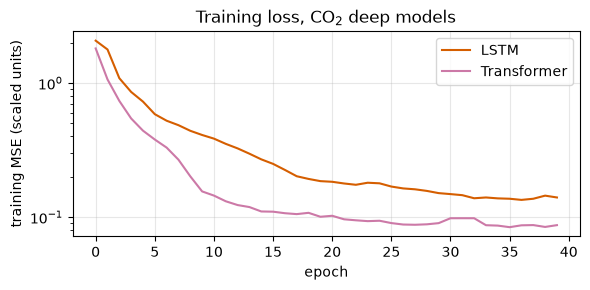

In [15]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(lstm_losses, color=COLORS["LSTM"], lw=1.5, label="LSTM")
ax.plot(tfm_losses, color=COLORS["Transformer"], lw=1.5, label="Transformer")
ax.set_xlabel("epoch")
ax.set_ylabel("training MSE (scaled units)")
ax.set_yscale("log")
ax.set_title("Training loss, CO$_2$ deep models")
ax.legend()
fig.tight_layout()
plt.show()

### 3.6 La comparación, calculada con honestidad

La tabla de abajo se construye de manera programática a partir de `results_co2`, el diccionario que `register()` llenó con las predicciones reales. Ningún número de la tabla se escribió a mano.

In [16]:
co2_table = pd.DataFrame(results_co2).T.sort_values("MASE").round(3)
co2_table

,MSE,RMSE,MAE,MAPE (%),MASE
SARIMA,0.129,0.359,0.281,0.067,0.256
Transformer,0.214,0.463,0.358,0.086,0.327
LSTM,1.085,1.042,0.886,0.212,0.808
LightGBM,1.643,1.282,1.030,0.246,0.939
seasonal naive,41.971,6.478,5.961,1.427,5.436
naive,56.380,7.509,6.679,1.596,6.090


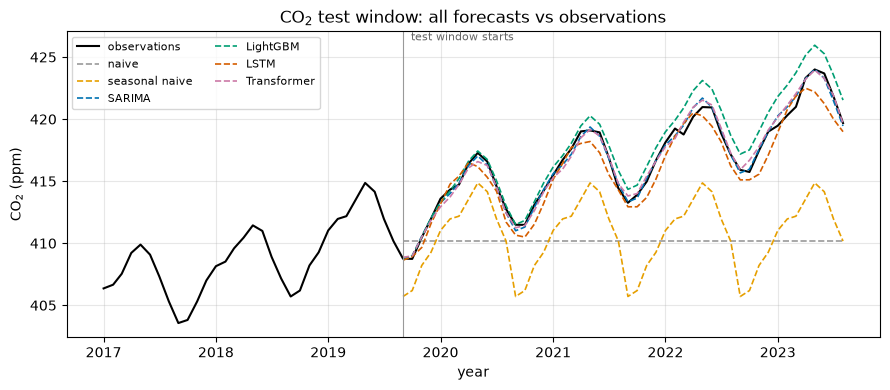

In [17]:
fig, ax = plt.subplots(figsize=(9, 4))
recent = y.loc["2017":]
ax.plot(recent.index, recent.values, color=COLORS["observations"],
        lw=1.5, label="observations")
for name, pred in preds_co2.items():
    ax.plot(test_co2.index, pred, color=COLORS[name], lw=1.2, ls="--", label=name)
ax.axvline(test_co2.index[0], color="0.6", lw=0.8)
ax.text(test_co2.index[0], ax.get_ylim()[1], "  test window starts",
        va="top", fontsize=8, color="0.4")
ax.set_xlabel("year")
ax.set_ylabel("CO$_2$ (ppm)")
ax.set_title("CO$_2$ test window: all forecasts vs observations")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

Qué buscar en su tabla y en su gráfica:

- La **persistencia ingenua** ignora tanto la tendencia como la estacionalidad; su línea plana es el piso al que todos deberían ganarle, y su MASE es grande porque un horizonte de 48 meses es mucho más difícil que el juego de un paso con el que se escala el MASE.
- El **ingenuo estacional** copia la forma anual pero congela la tendencia, así que deriva por debajo de las observaciones aproximadamente la tendencia multiplicada por el horizonte. Aun así, le gana a varios modelos entrenados. Esa es la lección recurrente de las comparativas de pronóstico.
- **SARIMA** codifica exactamente las dos cosas de las que está hecha esta serie, una tendencia diferenciada y un ciclo de 12 meses, en un puñado de parámetros. En este tipo de serie es muy difícil de superar.
- **LightGBM, LSTM y el *transformer*** tienen que aprender la tendencia y la estacionalidad a partir de ejemplos. En una corrida típica los tres alcanzan un MASE por debajo de 1 y quedan entre el modelo de referencia estacional y SARIMA; la realimentación recursiva (LightGBM) y los datos de entrenamiento limitados (el par profundo) cuestan exactitud en un horizonte de 4 años. El cuello de botella no es la capacidad del modelo; es la estructura del problema.

### 3.7 De pronósticos puntuales a intervalos: la pérdida pinball, la cobertura y el CRPS

Todos los modelos hasta aquí responden «¿cuánto será el CO$_2$?» con un solo número por mes. Ningún usuario serio de un pronóstico se conforma con eso: quien opera un embalse, quien analiza un presupuesto de carbono y todos los centros meteorológicos operativos piden el *rango* de resultados y qué tan probable es cada uno. La maquinaria es un cambio pequeño sobre lo que ya tenemos.

Un modelo aprende el **cuantil** $q_\tau$ del resultado cuando se entrena con la **pérdida pinball** (pérdida cuantílica)

$$\mathcal{L}_\tau(y, q) = \max\big(\tau\,(y - q),\ (\tau - 1)(y - q)\big),$$

que cobra $\tau$ por unidad de subpredicción y $1-\tau$ por unidad de sobrepredicción; el minimizador de su esperanza es exactamente el cuantil $\tau$. Prediga $q_{0.05}$ y $q_{0.95}$ y ya tiene un intervalo de predicción del 90%; $q_{0.5}$ es, de regalo, un pronóstico puntual mediano.

Le damos al LSTM de 3.4 una cabeza cuantílica: en lugar de 48 números emite $48 \times 19$ — uno por paso del horizonte y por nivel de cuantil $0.05, 0.10, \dots, 0.95$ — entrenada con la pérdida pinball promediada sobre los niveles. Las mismas ventanas, el mismo anclaje, las mismas épocas. Eso nos compra una afirmación *verificable*, y la verificación es el punto:

- **Cobertura empírica**: a lo largo de los 48 meses de prueba, ¿con qué frecuencia cae la observación realmente dentro del intervalo del 90%? Un pronóstico calibrado cubre alrededor del 90%. Menos significa que el modelo es demasiado confiado; mucho más significa que los intervalos son demasiado anchos para informar decisión alguna. Esta es la misma disciplina de calibración de las curvas de confiabilidad de los capítulos 3 y 4.5, aplicada a intervalos.
- Un detalle: las salidas cuantílicas entrenadas de manera independiente pueden **cruzarse** ($\hat q_{0.40} > \hat q_{0.45}$ en algún mes). Ordenar a lo largo del eje de cuantiles al momento de predecir es la reparación estándar de una línea, y la aplicamos abajo.

empirical coverage of the 90% interval: 91.7% (44/48 test months inside)
interval width: 2.33 ppm at 1 month -> 6.27 ppm at 48 months


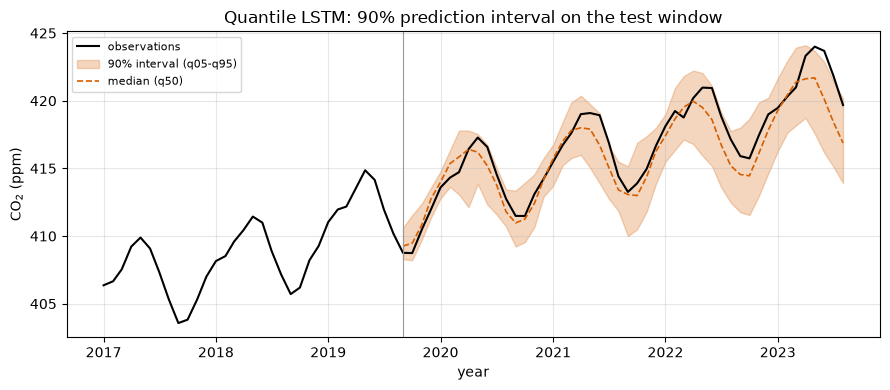

In [18]:
QUANTILES = np.round(np.arange(0.05, 0.951, 0.05), 2)   # 0.05, 0.10, ..., 0.95
N_Q = len(QUANTILES)
q_torch = torch.tensor(QUANTILES, dtype=torch.float32, device=device).view(1, 1, -1)

class QuantileLSTMForecaster(nn.Module):
    """The 3.4 LSTM with a (horizon x n_quantiles) head."""
    def __init__(self, horizon, n_q, hidden=32):
        super().__init__()
        self.horizon, self.n_q = horizon, n_q
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden, batch_first=True)
        self.head = nn.Linear(hidden, horizon * n_q)
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.head(h[-1]).view(-1, self.horizon, self.n_q)

def pinball_loss(pred, target):
    """Mean pinball loss over all quantile levels.
    pred: (batch, horizon, n_q); target: (batch, horizon)."""
    diff = target.unsqueeze(-1) - pred
    return torch.mean(torch.maximum(q_torch * diff, (q_torch - 1.0) * diff))

torch.manual_seed(0)
qlstm_co2 = QuantileLSTMForecaster(H_CO2, N_Q).to(device)
ds_q = torch.utils.data.TensorDataset(torch.from_numpy(Xc).unsqueeze(-1),
                                      torch.from_numpy(Yc))
dl_q = torch.utils.data.DataLoader(ds_q, batch_size=32, shuffle=True)
opt_q = torch.optim.Adam(qlstm_co2.parameters(), lr=1e-3)
for _ in range(40):
    qlstm_co2.train()
    for xb, yb in dl_q:
        xb, yb = xb.to(device), yb.to(device)
        opt_q.zero_grad()
        pinball_loss(qlstm_co2(xb), yb).backward()
        opt_q.step()

# Predict the test window, un-anchor, and sort along the quantile axis
# (independently trained quantile outputs can cross; sorting is the repair).
ctx = train_co2.to_numpy()[-CONTEXT_CO2:]
x_q = torch.from_numpy(((ctx - ctx[-1]) / scale_co2)
                       .astype(np.float32)).reshape(1, -1, 1).to(device)
qlstm_co2.eval()
with torch.no_grad():
    q_pred = qlstm_co2(x_q).cpu().numpy()[0]            # (48, 19), scaled units
q_pred = np.sort(q_pred, axis=1) * scale_co2 + ctx[-1]  # back to ppm
lo, med, hi = q_pred[:, 0], q_pred[:, N_Q // 2], q_pred[:, -1]  # q05, q50, q95

inside = (test_co2.values >= lo) & (test_co2.values <= hi)
print(f"empirical coverage of the 90% interval: {inside.mean():.1%} "
      f"({inside.sum()}/{len(inside)} test months inside)")
print(f"interval width: {hi[0] - lo[0]:.2f} ppm at 1 month -> "
      f"{hi[-1] - lo[-1]:.2f} ppm at 48 months")

fig, ax = plt.subplots(figsize=(9, 4))
recent = y.loc["2017":]
ax.plot(recent.index, recent.values, color=COLORS["observations"], lw=1.5,
        label="observations")
ax.fill_between(test_co2.index, lo, hi, color=COLORS["LSTM"], alpha=0.25,
                label="90% interval (q05-q95)")
ax.plot(test_co2.index, med, color=COLORS["LSTM"], lw=1.2, ls="--",
        label="median (q50)")
ax.axvline(test_co2.index[0], color="0.6", lw=0.8)
ax.set_xlabel("year")
ax.set_ylabel("CO$_2$ (ppm)")
ax.set_title("Quantile LSTM: 90% prediction interval on the test window")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

Digamos el número con todas sus letras: en esta corrida el intervalo del 90% atrapa **44 de 48 meses de prueba — una cobertura empírica del 91.7% frente a un 90% nominal**. Ese es un intervalo calibrado, y no estaba garantizado: la regresión cuantílica apunta a la calibración pero nada la impone fuera de muestra, y por eso usted calcula la cobertura en lugar de afirmarla. Dos advertencias honestas. Primero, 48 meses consecutivos desde un único origen de pronóstico están fuertemente correlacionados, así que esta estimación de cobertura es en sí misma ruidosa — una ventana de prueba distinta podría fácilmente devolver 80% o 100%. Segundo, mire las anchuras impresas: el intervalo crece de unas 2.3 ppm a un mes hasta unas 6.3 ppm a cuatro años. El modelo aprendió de las ventanas de entrenamiento que la incertidumbre se acumula con el horizonte de pronóstico; nadie se lo dijo.

**CRPS.** La cobertura verifica un intervalo a un nivel. El **puntaje de probabilidad clasificada continua (CRPS)** — la regla de calificación estándar de la verificación de pronósticos, el número que reportan los sistemas de ensambles atmosféricos — califica la distribución predictiva $F$ *entera* contra el resultado $y$:

$$\mathrm{CRPS}(F, y) = \int_{-\infty}^{\infty} \big(F(z) - \mathbf{1}\{z \ge y\}\big)^2\, dz \;=\; 2\int_0^1 \mathcal{L}_\tau\big(y, q_\tau\big)\, d\tau .$$

Tiene las unidades de los datos (aquí ppm), y para un pronóstico colapsado a un solo punto se reduce *exactamente* al error absoluto — de modo que el CRPS medio es directamente comparable con el MAE de un pronóstico puntual, y premia a la vez la calibración y la nitidez. La segunda identidad es también el estimador: promedie la pérdida pinball sobre una malla densa de cuantiles y multiplique por dos. Ya predecimos 19 cuantiles, así que la implementación son unas pocas líneas.

In [19]:
def crps_from_quantiles(y_true, q_pred, quantiles):
    """Quantile-based CRPS estimator: 2 x the pinball loss averaged over a
    dense quantile grid. Exact in the limit of a dense grid; with 19 levels
    it slightly undervalues the tails beyond q05/q95."""
    yv = np.asarray(y_true, dtype=float).reshape(-1, 1)
    diff = yv - np.asarray(q_pred, dtype=float)
    tau = np.asarray(quantiles, dtype=float).reshape(1, -1)
    return 2.0 * np.maximum(tau * diff, (tau - 1.0) * diff).mean(axis=1)

crps_q = crps_from_quantiles(test_co2.values, q_pred, QUANTILES)
print(f"mean CRPS, quantile LSTM       : {crps_q.mean():.3f} ppm")
print(f"MAE of its median (q50)        : {np.mean(np.abs(test_co2.values - med)):.3f} ppm")
print("point forecasts (CRPS = MAE):")
for name in ["LSTM", "SARIMA"]:
    print(f"  {name:12s}: {results_co2[name]['MAE']:.3f} ppm")

mean CRPS, quantile LSTM       : 0.766 ppm
MAE of its median (q50)        : 1.051 ppm
point forecasts (CRPS = MAE):
  LSTM        : 0.886 ppm
  SARIMA      : 0.281 ppm


Lea los tres números juntos. El CRPS medio del LSTM cuantílico (0.766 ppm) le gana al MAE de su propio pronóstico mediano (1.051 ppm) y al del LSTM de pronóstico puntual de 3.4 (0.886 ppm): repartir probabilidad sobre el rango donde puede caer el resultado gana puntaje real incluso cuando el centro es imperfecto. Esa comparación es el argumento entero a favor del pronóstico probabilístico, en una sola línea de salida. Pero el pronóstico puntual de SARIMA sigue ganando con 0.281 ppm — un punto bien colocado le gana a una distribución honestamente ancha. La calibración no excusa un centro sesgado o difuso; el lema de la comunidad de verificación es *nitidez sujeta a calibración*, y el siguiente contendiente natural sería la propia distribución de pronóstico de SARIMA (`get_forecast(...).conf_int()` da sus intervalos — pruebe a calificarlos).

### 3.8 Error frente al horizonte de pronóstico: el horizonte de habilidad

Un único MAE a 48 meses aplasta una dimensión entera de la calidad del pronóstico: **qué tan rápido decae la habilidad con el horizonte de pronóstico**. La verificación atmosférica nunca reporta un solo número; reporta el error como función del horizonte, porque un modelo que es excelente a 1 mes e inútil a 12 sirve a decisiones distintas de las de uno que es mediocre en todas partes.

Lo medimos con una evaluación de **origen deslizante**, tal como se califican los sistemas operativos. Los modelos permanecen congelados exactamente como fueron entrenados con datos hasta 2019-08 — sin reentrenamiento. El origen del pronóstico se desliza entonces mes a mes por la ventana de prueba; en cada origen el modelo ve el historial observado hasta ese mes (un pronosticador operativo siempre tiene las observaciones más recientes) y emite pronósticos para los horizontes 1 a 12. Promediar el error absoluto en cada horizonte sobre todos los orígenes da una curva de error frente al horizonte de pronóstico — con 37 orígenes por horizonte en lugar de la única muestra por horizonte que da un solo pronóstico de 48 meses.

El vocabulario que hay que llevarse: el **horizonte de habilidad** (*skill horizon*) es el horizonte de pronóstico más allá del cual un modelo deja de ganarle al pronóstico de referencia (aquí, la persistencia). Pasado ese punto, el modelo no agrega nada respecto de «sin cambios». Los modelos meteorológicos alcanzan su horizonte de habilidad alrededor de las dos semanas; la pregunta es dónde alcanzan el suyo estos modelos sobre el CO$_2$.

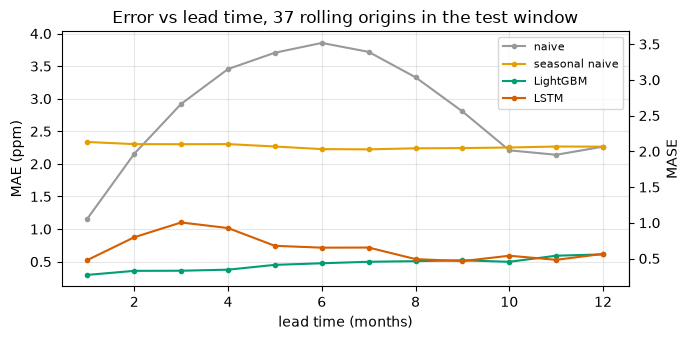

seasonal naive  beats persistence at leads: [3, 4, 5, 6, 7, 8, 9]
LightGBM        beats persistence at leads: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
LSTM            beats persistence at leads: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [20]:
LEADS = 12
LAGS_CO2, ROLL_CO2 = [1, 2, 3, 6, 12, 24], 12
y_vals = y.to_numpy()
first_test = len(train_co2)
origins = np.arange(first_test - 1, len(y) - LEADS)  # index of the last observed month

# One LightGBM fit on the training series only, reused frozen at every origin.
X_tr_lead, y_tr_lead = build_training_table(train_co2, LAGS_CO2, ROLL_CO2)
lgbm_frozen = LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=15,
                            random_state=0, verbose=-1).fit(X_tr_lead, y_tr_lead)

abs_err = {name: np.zeros((len(origins), LEADS))
           for name in ["naive", "seasonal naive", "LightGBM", "LSTM"]}
for r, j in enumerate(origins):
    hist = y_vals[:j + 1]                        # everything observed at the origin
    target = y_vals[j + 1:j + 1 + LEADS]
    abs_err["naive"][r] = np.abs(target - hist[-1])
    abs_err["seasonal naive"][r] = np.abs(target - y_vals[j + 1 - 12:j + 1 + LEADS - 12])
    h = list(hist)                               # LightGBM: recursive from observed history
    for step in range(LEADS):
        row = pd.DataFrame([lag_feature_row(np.asarray(h), y.index[j + 1 + step],
                                            LAGS_CO2, ROLL_CO2)])
        h.append(h[-1] + float(lgbm_frozen.predict(row)[0]))
    abs_err["LightGBM"][r] = np.abs(target - np.asarray(h[-LEADS:]))
    abs_err["LSTM"][r] = np.abs(target - nn_forecast(lstm_co2, hist[-CONTEXT_CO2:],
                                                     scale_co2)[:LEADS])

leads = np.arange(1, LEADS + 1)
lead_mae = pd.DataFrame({name: e.mean(axis=0) for name, e in abs_err.items()},
                        index=leads)
naive_train_mae_co2 = np.mean(np.abs(np.diff(train_co2.values)))

fig, ax = plt.subplots(figsize=(7, 3.5))
for name in lead_mae.columns:
    ax.plot(leads, lead_mae[name], color=COLORS[name], lw=1.5, marker="o",
            ms=3, label=name)
sec = ax.secondary_yaxis("right", functions=(lambda v: v / naive_train_mae_co2,
                                             lambda v: v * naive_train_mae_co2))
sec.set_ylabel("MASE")
ax.set_xlabel("lead time (months)")
ax.set_ylabel("MAE (ppm)")
ax.set_title(f"Error vs lead time, {len(origins)} rolling origins in the test window")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

for name in ["seasonal naive", "LightGBM", "LSTM"]:
    wins = leads[lead_mae[name].values < lead_mae["naive"].values]
    print(f"{name:15s} beats persistence at leads: {wins.tolist()}")

La curva y la comprobación impresa responden la pregunta del horizonte de habilidad, y en el CO$_2$ la respuesta es lo contrario de lo que ocurre en meteorología. La persistencia se degrada de manera sostenida con el horizonte — la tendencia y el ciclo estacional alejan la serie cada vez más de «sin cambios» — mientras que el error de los modelos entrenados crece mucho más despacio. **LightGBM y el LSTM le ganan a la persistencia en todos los horizontes de 1 a 12 meses: su horizonte de habilidad queda más allá de un año**, más allá del horizonte más largo que medimos. Los modelos meteorológicos pierden frente a la climatología en unas dos semanas porque el caos atmosférico destruye la información del estado inicial; el CO$_2$ mensual conserva su habilidad porque la estructura que sostiene el pronóstico (tendencia más ciclo anual) nunca deja de aplicarse. El horizonte de habilidad es una propiedad de la *serie* tanto como del modelo.

Los pronósticos de referencia siguen siendo instructivos. El ingenuo estacional le gana a la persistencia solo en horizontes intermedios (de 3 a 9 en esta corrida): en los horizontes 1-2 el valor del mes pasado está simplemente muy cerca de la verdad, y cerca del horizonte 12 la persistencia aterriza de nuevo en la misma estación, cerrando la mayor parte de la brecha. Así que hasta la elección de la referencia depende del horizonte de pronóstico — una razón más por la que un resumen de la habilidad de pronóstico en un solo número esconde más de lo que muestra. Para una serie donde el horizonte de habilidad llega casi de inmediato, corra esta misma evaluación de origen deslizante sobre la serie de Jakobshavn de la sección 4.

### 3.9 ¿Es estable el ordenamiento? Dispersión entre semillas

La sección 4 advertirá que los ordenamientos obtenidos de series cortas son inestables entre semillas aleatorias. La misma confesión aplica justo aquí, así que la cuantificamos en lugar de dejarla como advertencia. Todos los números de la tabla de 3.6 salieron de **una sola** corrida de entrenamiento; una entrada de la tabla es una muestra de una distribución sobre semillas, y reportar una muestra como si fuera la media es el mismo pecado que reportar un pronóstico puntual sin intervalo.

La sensibilidad a la semilla difiere según la clase de modelo, y eso es parte de la lección:

- **ingenuo, ingenuo estacional y SARIMA** son deterministas: sin semilla, sin dispersión.
- **LightGBM** acepta un `random_state`, pero tal como está configurado aquí (sin submuestreo de filas ni de características) el algoritmo también es determinista — la semilla es una perilla inerte hasta que usted habilite el *bagging*. Corremos 5 semillas para demostrarlo, no para estimar una dispersión.
- **El LSTM y el *transformer*** son estocásticos por partida doble: inicialización de pesos y barajado de los lotes (más el *dropout*, en el caso del *transformer*). Estas son las entradas cuya posición en la tabla usted debería desconfiar si viene de una sola corrida. También son las entradas lentas, así que usamos 3 semillas para cada una en lugar de 5, y lo decimos.

In [21]:
def mase_of(pred):
    return forecast_metrics(test_co2.values, pred, train_co2.values)["MASE"]

seed_mase = {}
seed_mase["LightGBM"] = [
    mase_of(lgbm_recursive_forecast(train_co2, test_co2.index,
                                    lags=[1, 2, 3, 6, 12, 24], roll=12,
                                    random_state=s)[0])
    for s in range(5)
]

def deep_seed_mase(model_cls, seed):
    torch.manual_seed(seed)
    m = model_cls(horizon=H_CO2)
    train_forecaster(m, Xc, Yc, epochs=40)
    return mase_of(nn_forecast(m, train_co2.to_numpy()[-CONTEXT_CO2:], scale_co2))

# Seed 0 is the run already in the 3.6 table; two more per deep model. Three
# seeds, not five: these are the slow entries, and the spread they show is
# already unmistakable.
seed_mase["LSTM"] = ([results_co2["LSTM"]["MASE"]]
                     + [deep_seed_mase(LSTMForecaster, s) for s in (1, 2)])
seed_mase["Transformer"] = ([results_co2["Transformer"]["MASE"]]
                            + [deep_seed_mase(TransformerForecaster, s) for s in (1, 2)])

spread_table = pd.DataFrame({
    name: {"MASE mean": np.mean(v), "MASE std": np.std(v),
           "MASE min": np.min(v), "MASE max": np.max(v), "seeds": len(v)}
    for name, v in seed_mase.items()}).T.round(3)
spread_table

,MASE mean,MASE std,MASE min,MASE max,seeds
LightGBM,0.939,0.000,0.939,0.939,5.0
LSTM,0.827,0.021,0.808,0.856,3.0
Transformer,0.356,0.034,0.327,0.403,3.0


La tabla de dispersión afina el ordenamiento de 3.6 en vez de derribarlo — y muestra exactamente dónde vive la aleatoriedad:

- **LightGBM** registra el mismo MASE en las cinco semillas (desviación estándar 0.000), tal como se prometió: sin submuestreo de filas ni de características el algoritmo es determinista, y «variamos la semilla» es evidencia de robustez solo cuando el algoritmo efectivamente consume la semilla.
- El **LSTM** abarca 0.808-0.856 (media 0.827, desviación estándar 0.021); el ***transformer*** abarca 0.327-0.403 (media 0.356, desviación estándar 0.034) — una décima parte de su propia media, solo por la inicialización, el orden de los lotes y el *dropout*.
- Los rangos no se solapan entre sí, ni con el 0.256 determinista de SARIMA, ni con el 0.939 de LightGBM, así que en esta corrida el orden del duelo sobrevive a las semillas. Esa es una conclusión que ahora podemos enunciar con evidencia en vez de con esperanza — y no es una ley general. En la serie de hielo de abajo, las brechas entre modelos son del mismo tamaño que dispersiones como estas, y por eso su ordenamiento no debería creerse a partir de una sola corrida. Reporte la media y la dispersión; deje que quien lea vea si las brechas le ganan al ruido.

## 4. La serie de hielo: una prueba más dura

Pasamos la serie de hielo solo por los modelos de referencia, ARIMA, LightGBM y el LSTM. Menos modelos a propósito: la serie es corta (unas 350 muestras de entrenamiento), muestreada de manera irregular y no está dominada por un ciclo estacional limpio, así que un SARIMA estacional tiene poco de dónde agarrarse y un *transformer* tiene muy pocos datos para justificar sus parámetros. Agregarlos rellenaría la tabla, no la comprensión.

### 4.1 Modelos de referencia y ARIMA

El muestreo promedia unas 46 muestras por año, así que el «ingenuo estacional» replica las últimas 46 muestras de entrenamiento como copia aproximada del último año; con muestreo irregular esta alineación es solo aproximada, una razón más por la que la maquinaria estacional ayuda menos aquí. Para la entrada clásica usamos un ARIMA(1,1,1) simple, sin términos estacionales.

In [22]:
from statsmodels.tsa.arima.model import ARIMA

H_ICE = len(test_ice)
m_ice = 46   # approx. one year (~46 samples/yr on average)

naive_ice = np.full(H_ICE, train_ice.iloc[-1])
seasonal_ice = np.tile(train_ice.values[-m_ice:],
                       int(np.ceil(H_ICE / m_ice)))[:H_ICE]

register(results_ice, preds_ice, "naive", naive_ice, test_ice, train_ice)
register(results_ice, preds_ice, "seasonal naive", seasonal_ice, test_ice, train_ice)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    arima_ice = ARIMA(train_ice.values, order=(1, 1, 1)).fit()
register(results_ice, preds_ice, "ARIMA", arima_ice.forecast(H_ICE), test_ice, train_ice)

naive -> {'MSE': np.float64(34556.717), 'RMSE': np.float64(185.894), 'MAE': np.float64(168.382), 'MAPE (%)': np.float64(9.589), 'MASE': np.float64(6.249)}
seasonal naive -> {'MSE': np.float64(23662.811), 'RMSE': np.float64(153.827), 'MAE': np.float64(129.081), 'MAPE (%)': np.float64(7.237), 'MASE': np.float64(4.79)}
ARIMA -> {'MSE': np.float64(32800.223), 'RMSE': np.float64(181.108), 'MAE': np.float64(163.157), 'MAPE (%)': np.float64(9.297), 'MASE': np.float64(6.055)}


### 4.2 LightGBM y el LSTM, reutilizados

Los mismos ayudantes, nuevos conjuntos de rezagos: rezagos de hasta 46 muestras (aproximadamente un año) y una media móvil corta. El LSTM usa un contexto de aproximadamente un año (46 muestras) y pronostica la ventana de prueba completa de manera directa, como antes.

In [23]:
lgbm_pred_ice, _ = lgbm_recursive_forecast(train_ice, test_ice.index,
                                           lags=[1, 2, 3, 6, 23, 46], roll=6)
register(results_ice, preds_ice, "LightGBM", lgbm_pred_ice, test_ice, train_ice)

LightGBM -> {'MSE': np.float64(13027.719), 'RMSE': np.float64(114.139), 'MAE': np.float64(94.373), 'MAPE (%)': np.float64(5.338), 'MASE': np.float64(3.502)}


In [24]:
CONTEXT_ICE = 46
Xi, Yi = make_windows(train_ice.to_numpy(), CONTEXT_ICE, H_ICE)
scale_ice = float(Xi.std())
Xi, Yi = Xi / scale_ice, Yi / scale_ice
print(f"{len(Xi)} training windows, scale = {scale_ice:.0f} m/yr")

torch.manual_seed(0)
lstm_ice = LSTMForecaster(horizon=H_ICE)
_ = train_forecaster(lstm_ice, Xi, Yi, epochs=40)
lstm_pred_ice = nn_forecast(lstm_ice, train_ice.to_numpy()[-CONTEXT_ICE:], scale_ice)
register(results_ice, preds_ice, "LSTM", lstm_pred_ice, test_ice, train_ice)

213 training windows, scale = 83 m/yr


LSTM -> {'MSE': np.float64(52166.004), 'RMSE': np.float64(228.399), 'MAE': np.float64(191.047), 'MAPE (%)': np.float64(10.931), 'MASE': np.float64(7.09)}


In [25]:
ice_table = pd.DataFrame(results_ice).T.sort_values("MASE").round(3)
ice_table

,MSE,RMSE,MAE,MAPE (%),MASE
LightGBM,13027.719,114.139,94.373,5.338,3.502
seasonal naive,23662.811,153.827,129.081,7.237,4.790
ARIMA,32800.223,181.108,163.157,9.297,6.055
naive,34556.717,185.894,168.382,9.589,6.249
LSTM,52166.004,228.399,191.047,10.931,7.090


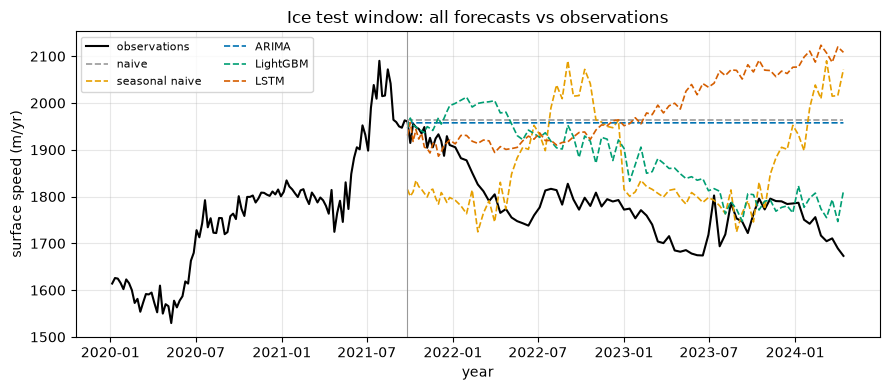

In [26]:
fig, ax = plt.subplots(figsize=(9, 4))
recent_ice = ice.loc["2020":]
ax.plot(recent_ice.index, recent_ice.values, color=COLORS["observations"],
        lw=1.5, label="observations")
for name, pred in preds_ice.items():
    ax.plot(test_ice.index, pred, color=COLORS[name], lw=1.2, ls="--", label=name)
ax.axvline(test_ice.index[0], color="0.6", lw=0.8)
ax.set_xlabel("year")
ax.set_ylabel("surface speed (m/yr)")
ax.set_title("Ice test window: all forecasts vs observations")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

Note cuánto más grandes son los valores de MASE que en el CO$_2$, en todos los modelos. El juego ingenuo de un paso (el denominador del MASE) es fácil en una serie de velocidad que varía lentamente, pero la ventana de prueba plurianual contiene cambios en el comportamiento del glaciar que ningún patrón de la ventana de entrenamiento anuncia. Cuando el futuro no está escrito en el pasado, más modelo no significa más pronóstico. Espere además que el ordenamiento entre los modelos entrenados sea inestable aquí: con ~340 muestras de entrenamiento, decisiones pequeñas (longitud del contexto, conjunto de rezagos, semilla aleatoria) mueven modelos hacia arriba y hacia abajo en la tabla — medimos exactamente ese efecto en el duelo del CO$_2$ en la sección 3.9, y es peor en una serie así de corta. Repórtelo con honestidad en lugar de ir de compras buscando la configuración que se vea mejor.

## 5. Los eventos raros rompen las métricas del grueso de los datos

El problema de datos que define a las geociencias es un campo que varía suavemente durante años y después hace algo extremo durante tres días: crecidas en un registro de caudal, erupciones en un registro de tremor, saltos en un registro de deformación. Todas las métricas de este cuaderno hasta ahora promedian sobre *todas* las muestras de prueba, y las muestras tranquilas superan a las de eventos en una proporción de unos doce a uno — así que un modelo puede registrar un MAE excelente mientras se pierde todos los eventos que importan.

Para mostrarlo con claridad necesitamos verdad de referencia sobre los eventos, así que construimos la serie nosotros mismos con `mlgeo_synth.inject_rare_events`: ocho años de un fondo estacional diario, salpicado por ~6 eventos al año que duran de 2 a 6 días, con amplitudes sorteadas de una **distribución de Pareto generalizada** (`tail="gpd"`, parámetro de forma $\xi = 0.5$). Eso es una cola de ley de potencias — el régimen de valores extremos de los registros reales de crecidas y de marea de tormenta, donde la varianza es infinita y el evento más grande de cualquier ventana futura es rutinariamente varias veces mayor que el más grande observado hasta la fecha. El generador devuelve una columna `amplitude`: el tamaño verdadero sorteado de cada evento, exactamente la verdad de referencia que una métrica del grueso de los datos nunca ve.

Al pronosticador se le dan a propósito todas las ventajas: LightGBM de un paso hacia adelante (el valor de ayer siempre está en el conjunto de características), entrenado con seis años y probado en los dos últimos. Después, en lugar de un solo MAE, **estratificamos** el error de prueba según la amplitud de la verdad de referencia.

                        n samples     MAE
all test samples              730   0.969
quiet (no event)              674   0.621
event, amplitude < 10          43   2.458
event, amplitude 10-25          7  10.577
event, amplitude >= 25          6  18.274

largest single miss: 50.8 (event amplitude 50.2)


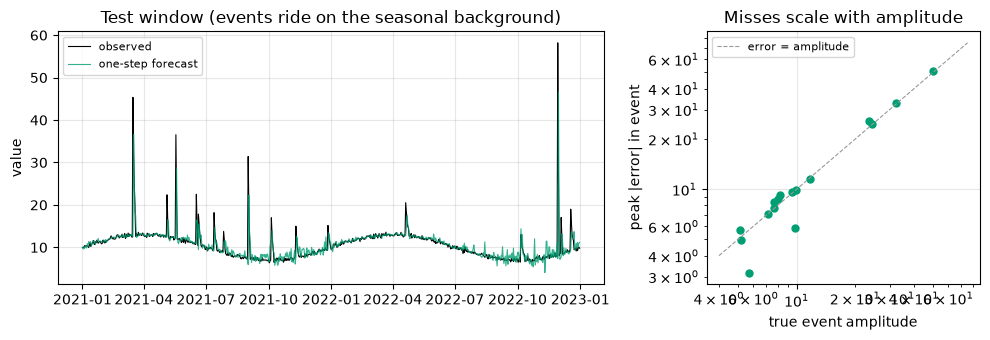

In [27]:
n_days_ev = int(8 * 365.25)
days_ev = pd.date_range("2015-01-01", periods=n_days_ev, freq="D")
rng_ev = np.random.default_rng(0)
background_ev = (10.0 + 3.0 * np.sin(2 * np.pi * np.arange(n_days_ev) / 365.25)
                 + 0.3 * rng_ev.standard_normal(n_days_ev))
events = mlgeo_synth.inject_rare_events(background_ev, rate_per_year=6.0,
                                        duration_days=(2, 6), shape="spike",
                                        tail="gpd", seed=7)
series_ev = pd.Series(events["value"].to_numpy(), index=days_ev)

# One-step-ahead LightGBM on lag features — the easiest possible forecasting
# task: the model always has yesterday's observation in hand.
LAGS_EV, ROLL_EV = [1, 2, 3, 5, 7, 14, 365], 7
X_ev, dy_ev = build_training_table(series_ev, LAGS_EV, ROLL_EV)
start_ev = max(max(LAGS_EV), ROLL_EV)
dates_ev = series_ev.index[start_ev:]
cut = dates_ev.searchsorted(pd.Timestamp("2021-01-01"))   # train < 2021 <= test

lgbm_ev = LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=15,
                        random_state=0, verbose=-1).fit(X_ev.iloc[:cut], dy_ev[:cut])
pred_ev = (series_ev.to_numpy()[start_ev - 1:-1][cut:]
           + lgbm_ev.predict(X_ev.iloc[cut:]))            # previous value + predicted change
true_ev = series_ev.to_numpy()[start_ev:][cut:]
err_ev = np.abs(true_ev - pred_ev)

# Stratify by the generator's ground-truth amplitude column.
evt = events.iloc[start_ev:].iloc[cut:]                   # aligned truth columns
quiet = evt["event"].to_numpy() == 0
amp = evt["amplitude"].to_numpy()
strata = {
    "all test samples":        np.ones_like(quiet),
    "quiet (no event)":        quiet,
    "event, amplitude < 10":   ~quiet & (amp < 10),
    "event, amplitude 10-25":  ~quiet & (amp >= 10) & (amp < 25),
    "event, amplitude >= 25":  ~quiet & (amp >= 25),
}
tail_table = pd.DataFrame({name: {"n samples": int(m.sum()),
                                  "MAE": err_ev[m].mean()}
                           for name, m in strata.items()}).T
tail_table["n samples"] = tail_table["n samples"].astype(int)
print(tail_table.round(3))
print(f"\nlargest single miss: {err_ev.max():.1f} "
      f"(event amplitude {amp[np.argmax(err_ev)]:.1f})")

# Left: the test window. Right: per-event peak error vs true amplitude.
per_event = (pd.DataFrame({"event_id": evt["event_id"].to_numpy(),
                           "amp": amp, "err": err_ev})
             .query("event_id >= 0").groupby("event_id")
             .agg(amp=("amp", "max"), peak_err=("err", "max")))
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5),
                         gridspec_kw={"width_ratios": [2, 1]})
axes[0].plot(dates_ev[cut:], true_ev, color=COLORS["observations"], lw=0.8,
             label="observed")
axes[0].plot(dates_ev[cut:], pred_ev, color=COLORS["LightGBM"], lw=0.8,
             alpha=0.8, label="one-step forecast")
axes[0].set_ylabel("value")
axes[0].set_title("Test window (events ride on the seasonal background)")
axes[0].legend(fontsize=8)
axes[1].loglog(per_event["amp"], per_event["peak_err"], "o", ms=5,
               color=COLORS["LightGBM"])
lim = [4, per_event["amp"].max() * 1.5]
axes[1].plot(lim, lim, color="0.6", lw=0.8, ls="--", label="error = amplitude")
axes[1].set_xlabel("true event amplitude")
axes[1].set_ylabel("peak |error| in event")
axes[1].set_title("Misses scale with amplitude")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

Una lectura ingenua de la primera fila dice que el modelo es excelente: MAE de 0.97 en una serie cuya oscilación estacional por sí sola vale 6 unidades. Las filas estratificadas cuentan la historia verdadera. Los días tranquilos puntúan 0.62 — el piso de ruido, lo mejor que llega a dar el pronóstico de un paso. Los eventos pequeños (amplitud por debajo de 10) ya cuestan 2.5. Las siete muestras de eventos de tamaño medio cuestan unos 10.6, las seis muestras de los eventos más grandes cuestan 18.3, y el evento más grande de todos — amplitud 50.2 — se falla por 50.8: **el modelo predijo el fondo estacional y la crecida ocurrió de todas formas**. El panel derecho lo vuelve sistemático: el error máximo por evento sigue a la amplitud verdadera a lo largo de la línea error-igual-a-amplitud. Lo que el modelo nunca ha visto, lo falla por completo.

Ambas causas son estructurales, no errores de programación. Los inicios de los eventos son impredecibles a partir de características de rezago — ningún valor de ayer le dice que mañana empieza un pico — y la cola GPD ($\xi = 0.5$) garantiza que la ventana de prueba contenga amplitudes más allá de todo ejemplo de entrenamiento, de modo que el modelo está extrapolando precisamente en las muestras que más importan. Mientras tanto, la métrica del grueso de los datos lo esconde todo: las muestras de eventos son 56 de 730 días de prueba (una de cada trece, aproximadamente), así que el MAE global (0.97) queda dentro de un factor de 1.6 del piso de los días tranquilos, mientras que el estrato superior es treinta veces peor. Una tabla de clasificación calificada con el MAE global felicitaría a este modelo.

La reparación está en la métrica, no en el modelo: si los eventos son la razón de ser de su pronóstico — crecidas, erupciones, saltos —, califíquelos por separado. Tablas estratificadas como esta, exhaustividad (*recall*) por ventana de evento o pérdidas ponderadas por amplitud, todas funcionan; promediar sobre los días tranquilos, no. Esta es la misma disciplina de evaluación justa que la pista oculta de la tabla de clasificación de más abajo: lo que usted mide es lo que optimiza, así que mida lo que importa.

## 6. Ejercicios

**Ejercicio 1.** En la entrada de LightGBM para el CO$_2$, quite `lag_12` y `lag_24` de la lista de rezagos y vuelva a correr. ¿Qué le pasa al MASE, y por qué?

```{admonition} Solución
:class: dropdown
El MASE empeora. Los rezagos de 12 y 24 meses son la forma en que el modelo ve el ciclo anual; sin ellos tiene que reconstruir la estacionalidad solo a partir de la característica del mes calendario y de los rezagos cortos, y el pronóstico recursivo se aparta lentamente de la forma estacional. Corra
`lgbm_recursive_forecast(train_co2, test_co2.index, lags=[1, 2, 3, 6], roll=12)`
y compare las métricas con `forecast_metrics`.
```

**Ejercicio 2.** Los modelos profundos pronostican los 48 meses de una sola vez (varios pasos de manera directa); LightGBM predice un mes a la vez y realimenta sus predicciones (recursivo). Nombre una ventaja de cada estrategia.

```{admonition} Solución
:class: dropdown
Directa: no hay realimentación del error, así que un paso temprano malo no puede contaminar los pasos posteriores, y el modelo se entrena exactamente sobre el horizonte con el que se lo califica. Recursiva: un solo modelo sirve para cualquier horizonte, y el entrenamiento de un paso usa muchos más ejemplos por parámetro; pero los errores se acumulan a lo largo del horizonte. Existen híbridos (un modelo directo por paso, o esquemas de «rectificación») exactamente por este compromiso.
```

**Ejercicio 3.** Vuelva a correr la sección 5 dos veces: una con `tail="uniform"` (el valor por defecto del generador: amplitudes uniformes entre 5 y 20) y otra manteniendo `tail="gpd"` pero subiendo `rate_per_year` a 24. ¿Cuál de los dos cambios hace más por el estrato de eventos grandes, y qué le dice eso sobre la diferencia entre *raro* y *de cola pesada*?

```{admonition} Solución
:class: dropdown
La cola uniforme ayuda más. Con amplitudes limitadas a 20, la ventana de entrenamiento ya le mostró al modelo eventos tan grandes como cualquiera con el que se lo vaya a calificar — el problema es de interpolación, y más ejemplos (una tasa mayor) lo pulen. Con una cola GPD el evento futuro más grande queda más allá de todo ejemplo de entrenamiento casi por construcción, así que ninguna tasa de eventos realista arregla el estrato superior: se le pide al modelo que extrapole. La rareza limita cuántos ejemplos obtiene usted; una cola pesada garantiza que el examen contenga una magnitud que el libro de texto nunca mostró. (El ejercicio fuera de distribución del capítulo 4.5 es la misma lección en el espacio de características.)
```

## 7. La tabla de clasificación de la clase: dos pistas

Ahora los 12 meses que quitamos en la sección 1.2 vuelven al juego — pero primero, una declaración honesta sobre lo que una tabla de clasificación pública puede y no puede medir.

```{admonition} El puntaje público de CO₂ es un diagnóstico — y es trivialmente manipulable
:class: warning
Los meses reservados son datos públicos de la NOAA. El archivo con la verdad (`leaderboard/co2_holdout.csv`) está en el repositorio del curso, y el registro completo de Mauna Loa queda en caché en su propio disco por la llamada a `pooch` de la sección 1.1. Copiar esos números en una entrega da un MASE perfecto de 0.0 — y, de manera más sutil, también lo da «pronosticar» con cualquier modelo que haya espiado el conjunto reservado. Por eso esta pista **no tiene peso en la calificación**: existe para que usted ejercite el flujo de entrega y compare intentos honestos. Una tabla de clasificación solo es tan significativa como inaccesible sea su conjunto reservado — la misma razón por la que el puntaje público de clasificación del capítulo 3.5 es un diagnóstico mientras que su peso de calificación descansa sobre un conjunto de prueba oculto. La pista calificada de abajo pronostica una serie cuyo futuro existe solo en la máquina del instructor.
```

**Pista A — CO$_2$ (diagnóstico).**

1. Produzca un pronóstico de CO$_2$ a 12 meses para **2023-09 a 2024-08**, los meses reservados, usando cualquier modelo entrenado únicamente con datos hasta 2023-08. Por su honor — vea el recuadro de arriba para entender por qué hacer trampa aquí solo arruina el diagnóstico.
2. Guárdelo en `results/forecast_<uwnetid>.csv` con exactamente dos columnas: `date` (como `YYYY-MM`) y `co2_ppm`.
3. Entréguelo mediante un *pull request* al repositorio del libro del curso, [https://github.com/geo-smart/mlgeo-book](https://github.com/geo-smart/mlgeo-book). La CI califica cada PR y publica la clasificación.

La calificación es el MASE contra los meses reservados, escalado por el MAE ingenuo de un paso de la serie de *entrenamiento* (la misma convención que `forecast_metrics` en la sección 2.2 — el denominador viene del registro previo al conjunto reservado, no del conjunto reservado mismo).

**Pista B — la serie sintética oculta (calificada).** El archivo `leaderboard/synth_forecast_history.csv` del repositorio del curso contiene una serie diaria de desplazamiento generada con `mlgeo_synth.gnss_series` — tendencia secular, ciclos anual y semianual, y ruido de color, como los registros GNSS del capítulo 2 — producida a partir de una semilla privada y regenerada cada año. Pronostique los **90 días posteriores a la última fecha del historial** y guarde `results/forecast_hidden_<uwnetid>.csv` con las columnas `date` (`YYYY-MM-DD`) y `disp_mm`, entregado en el mismo *pull request*. La serie de verdad nunca se sube al repositorio; la tabla de clasificación pública lista su entrega como *recibida*, y la corrida del instructor produce la tabla calificada. La misma métrica: MASE, escalado por el error ingenuo de un paso del historial.

Las celdas de abajo escriben un archivo de ejemplo para cada pista usando el modelo LightGBM recursivo. Reemplace `example` por su UW NetID y los pronósticos por los suyos.

In [28]:
uwnetid = "example"   # <-- replace with your UW NetID

# Track A: refit on ALL pre-holdout data (through 2023-08) and forecast the
# 12 holdout months.
final_pred, _ = lgbm_recursive_forecast(y, holdout_months,
                                        lags=[1, 2, 3, 6, 12, 24], roll=12)

submission = pd.DataFrame({"date": holdout_months.strftime("%Y-%m"),
                           "co2_ppm": np.round(final_pred, 2)})
os.makedirs("results", exist_ok=True)
out_path = f"results/forecast_{uwnetid}.csv"
submission.to_csv(out_path, index=False)
print("wrote", out_path)
print(submission.to_string(index=False))

wrote results/forecast_example.csv
   date  co2_ppm
2023-09   418.23
2023-10   418.42
2023-11   419.86
2023-12   421.29
2024-01   422.44
2024-02   423.25
2024-03   424.07
2024-04   425.49
2024-05   426.23
2024-06   425.65
2024-07   423.90
2024-08   421.89


In [29]:
# Track B: forecast the hidden synthetic series 90 days past its history.
hist_path = Path("../../leaderboard/synth_forecast_history.csv")
if not hist_path.exists():          # running outside the repo checkout
    hist_path = Path(pooch.retrieve(
        "https://raw.githubusercontent.com/geo-smart/mlgeo-book/main/"
        "leaderboard/synth_forecast_history.csv",
        known_hash=None, fname="synth_forecast_history.csv"))
hidden_hist = pd.read_csv(hist_path, parse_dates=["date"])
hidden_series = pd.Series(hidden_hist["disp_mm"].to_numpy(),
                          index=pd.DatetimeIndex(hidden_hist["date"]))
horizon_dates = pd.date_range(hidden_series.index[-1] + pd.Timedelta(days=1),
                              periods=90, freq="D")
print(f"history: {len(hidden_series)} days ending {hidden_series.index[-1].date()}; "
      f"forecast {horizon_dates[0].date()} .. {horizon_dates[-1].date()}")

hidden_pred, _ = lgbm_recursive_forecast(hidden_series, horizon_dates,
                                         lags=[1, 2, 3, 7, 14, 365], roll=7)
hidden_sub = pd.DataFrame({"date": horizon_dates.strftime("%Y-%m-%d"),
                           "disp_mm": np.round(hidden_pred, 3)})
hidden_out = f"results/forecast_hidden_{uwnetid}.csv"
hidden_sub.to_csv(hidden_out, index=False)
print("wrote", hidden_out)
hidden_sub.head()

history: 2832 days ending 2022-10-02; forecast 2022-10-03 .. 2022-12-31


wrote results/forecast_hidden_example.csv


,date,disp_mm
0,2022-10-03,93.733
1,2022-10-04,94.187
2,2022-10-05,93.695
3,2022-10-06,94.463
4,2022-10-07,93.498


## Resumen

- Modelos de referencia primero: los pronósticos ingenuo e ingenuo estacional ponen la vara, y el MASE mide a todo modelo contra el juego ingenuo de un paso.
- Una división temporal, un ayudante de métricas, una tabla programática. Las divisiones aleatorias y los números escritos a mano son la forma en que la edición 2024 se equivocó; no repita ninguna de las dos.
- En series largas y estructuradas (CO$_2$), un modelo clásico bien elegido (SARIMA) es difícil de superar, y los modelos profundos necesitan cuidados (anclaje, escalado) solo para competir. En series cortas e irregulares (Jakobshavn), todos los modelos batallan, y decirlo es el resultado correcto.
- El pronóstico recursivo frente al directo de varios pasos es una decisión de diseño real; usamos el recursivo para LightGBM y el directo para el LSTM y el *transformer*.
- Un pronóstico puntual es el comienzo, no el final. Una cabeza cuantílica entrenada con la pérdida pinball produjo un intervalo del 90% cuya cobertura empírica medimos en lugar de suponer, y el CRPS — la generalización del MAE en verificación — calificó la distribución entera.
- El error es función del horizonte de pronóstico; grafíquelo. El horizonte de habilidad — el horizonte en el que un modelo deja de ganarle a la persistencia — es el resumen operativo de un sistema de pronóstico.
- Un ordenamiento obtenido de una semilla es una sola muestra. Las entradas deterministas (modelos de referencia, SARIMA, esta configuración de LightGBM) tienen dispersión cero; las entradas profundas se mueven lo suficiente entre semillas como para intercambiar lugares. Reporte la media y la dispersión, no un solo sorteo.
- El MAE del grueso de los datos puede verse excelente mientras se falla todo evento raro grande: con amplitudes de cola pesada (GPD), el estrato superior de eventos cargó errores treinta veces el MAE de los días tranquilos, y el evento más grande se falló casi por completo. Estratifique su calificación, o su métrica esconderá exactamente las muestras que importan.
- La tabla de clasificación tiene dos pistas porque su conjunto reservado público son datos públicos: el puntaje de CO$_2$ es un diagnóstico (y trivialmente manipulable — lo decimos por escrito), mientras que la serie sintética oculta, regenerada cada año a partir de una semilla privada, carga con el peso de la calificación.

A continuación: entregue sus dos pronósticos para la tabla de clasificación y luego continúe con la asignación del proyecto final (4.20). Para las arquitecturas de secuencias en sí mismas, vuelva al cuaderno 4.4; para la maquinaria de *boosting*, al capítulo 3.